# Inverse design optimization of a mode converter

I wonder what happened if we binarize the waveguide into an arbitrary pixel pixel dimension after inverse design optimization. Will the performance of the mode converter degrade? How much?

In this notebook, we will use inverse design and Tidy3D to create an
integrated photonics component to convert a fundamental waveguide mode
to a higher order mode.

In [1]:
from typing import List

import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np

# import regular tidy3d
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad
from tidy3d.plugins.mode import ModeSolver

# set random seed to get same results
np.random.seed(2)

16:58:39 SE Asia Standard Time WARNING: Using canonical configuration directory 
                               at 'C:\Users\James\.config\tidy3d'. Found legacy 
                               directory at 'C:\Users\James\.tidy3d', which will
                               be ignored. Tidy3D configuration now uses        
                               'C:\Users\James\.config\tidy3d\config.toml'.     

## Setup

We wish to recreate a device like the diagram below:

<img src="img/AdjointInvDes.png" width=800 alt="Schematic of the mode converter">

A mode source is injected into a waveguide on the left-hand side. The
light propagates through a rectangular region with pixelated
permittivity with the value of each pixel independently tunable between
1 (vacuum) and some maximum permittivity. Finally, we measure the
transmission of the light into a waveguide on the right-hand side.

The goal of the inverse design exercise is to find the best distribution
of permittivities ($\epsilon_{ij}$) in the coupling region to maximize
the power conversion between the input mode and the output mode.

We also apply our built-in smoothening and binarization filters to
ensure that the final device has smooth features, and permittivity
values that are all either 1, or the maximum permittivity of the
waveguide material.

### Parameters

First we will define some parameters.

In [2]:
# wavelength and frequency
wavelength = 1.0
freq0 = td.C_0 / wavelength
k0 = 2 * np.pi * freq0 / td.C_0

# resolution control
min_steps_per_wvl = 16
# in the design region, we set uniform grid resolution,
# and define the design parameters on the same grid
dl_design_region = 0.01

# space between boxes and PML
buffer = 1.0 * wavelength

# optimize region size
lz = td.inf
lx = 5.0
ly = 3.0

# position of source and monitor (constant for all)
source_x = -lx / 2 - buffer * 0.8
meas_x = lx / 2 + buffer * 0.8

# total size
Lx = lx + 2 * buffer
Ly = ly + 2 * buffer
Lz = 0.0

# permittivity and width of the input/output waveguide
eps_wg = 2.75
wg_width = 0.7

# random starting parameters between 0 and 1
nx = int(lx / dl_design_region)
ny = int(ly / dl_design_region)
params0 = np.random.random((nx, ny))

# frequency width and run time
freqw = freq0 / 10
run_time = 50 / freqw

### Static Components

Next, we will set up the static parts of the geometry, the input source,
and the output monitor using these parameters.

In [3]:
waveguide = td.Structure(
    geometry=td.Box(size=(2 * Lx, wg_width, lz)), medium=td.Medium(permittivity=eps_wg)
)

mode_size = (0, wg_width * 3, lz)

source_plane = td.Box(
    center=[source_x, 0, 0],
    size=mode_size,
)

measure_plane = td.Box(
    center=[meas_x, 0, 0],
    size=mode_size,
)

### Input Structures

Next, we write a function to return the pixelated array given our
flattened tuple of permittivity values $\epsilon_{ij}$ using the
`tidy3d.plugins.autograd` plugin.

We start with an array of parameters between 0 and 1, apply a conic
filter and tanh projection to compute smooth, well-binarized features.

In [4]:
from tidy3d.plugins.autograd import make_filter_and_project, rescale

# radius of the circular filter (um) and the threshold strength
radius = 0.120
beta = 50

filter_project = make_filter_and_project(radius, lx / nx)


def get_eps(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0, 1)"""
    processed_params = filter_project(params, beta)
    eps = rescale(processed_params, 1, eps_wg)
    return eps


def make_input_structures(params, beta) -> List[td.Structure]:
    box = td.Box(center=(0, 0, 0), size=(lx, ly, lz))
    eps_data = get_eps(params, beta=beta).reshape((nx, ny, 1))
    custom_structure = td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)

    return [custom_structure]

### Making the Simulation

Next, we write a function to return a basic `td.Simulation` as a
function of our parameter values.

We make sure to add the pixelated `td.Structure` list to
`input_structures` but leave out the sources and monitors for now as
we’ll want to add those after the mode solver is run so we can inspect
them.

In [5]:
def make_sim_base(params: np.ndarray, beta: float) -> td.Simulation:
    """Create the simulation given the parameters and some beta value."""

    structures = make_input_structures(params, beta=beta)
    design_region_mesh = td.MeshOverrideStructure(
        geometry=td.Box(size=(lx, ly, lz)),
        dl=[dl_design_region] * 3,
        enforce=True,
    )
    grid_spec = td.GridSpec.auto(
        wavelength=wavelength,
        min_steps_per_wvl=16,
        override_structures=[design_region_mesh],
    )

    return td.Simulation(
        size=[Lx, Ly, Lz],
        grid_spec=grid_spec,
        structures=[waveguide] + structures,
        sources=[],
        monitors=[],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.pml(x=True, y=True, z=False),
    )

### Visualize

Let’s visualize the simulation to see how it looks

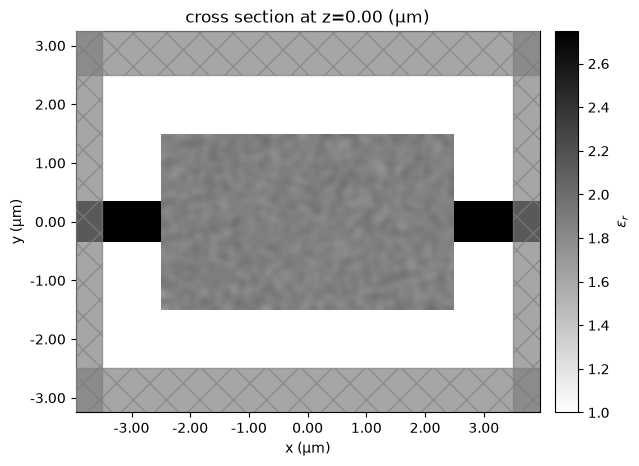

In [6]:
sim_start = make_sim_base(params0, beta=1.0)

ax = sim_start.plot_eps(z=0, freq=freq0)

plt.show()

### Select Input and Output Modes

Next, let’s visualize the first 4 mode profiles so we can select which
mode indices we want to inject and transmit.

In [7]:
from tidy3d.plugins.mode.web import run as run_mode_solver

num_modes = 4
mode_spec = td.ModeSpec(num_modes=num_modes)

mode_solver = ModeSolver(
    simulation=sim_start,
    plane=source_plane,
    mode_spec=td.ModeSpec(num_modes=num_modes),
    freqs=[freq0],
)
modes = run_mode_solver(mode_solver, reduce_simulation=True)

16:58:47 SE Asia Standard Time Mode solver created with                         
                               task_id='fdve-2c5c2a73-8045-4937-a540-08b48189bdc
                               8',                                              
                               solver_id='mo-aff0d00a-075e-4dc0-877e-8b22b403882
                               2'.

Output()

Output()

16:58:52 SE Asia Standard Time Mode solver status: queued

16:59:22 SE Asia Standard Time Mode solver status: running

16:59:24 SE Asia Standard Time Mode solver status: success

Output()

Let’s visualize the modes next.

Effective index of computed modes:  [[1.57207961 1.53546344 1.30320219 1.18494033]]


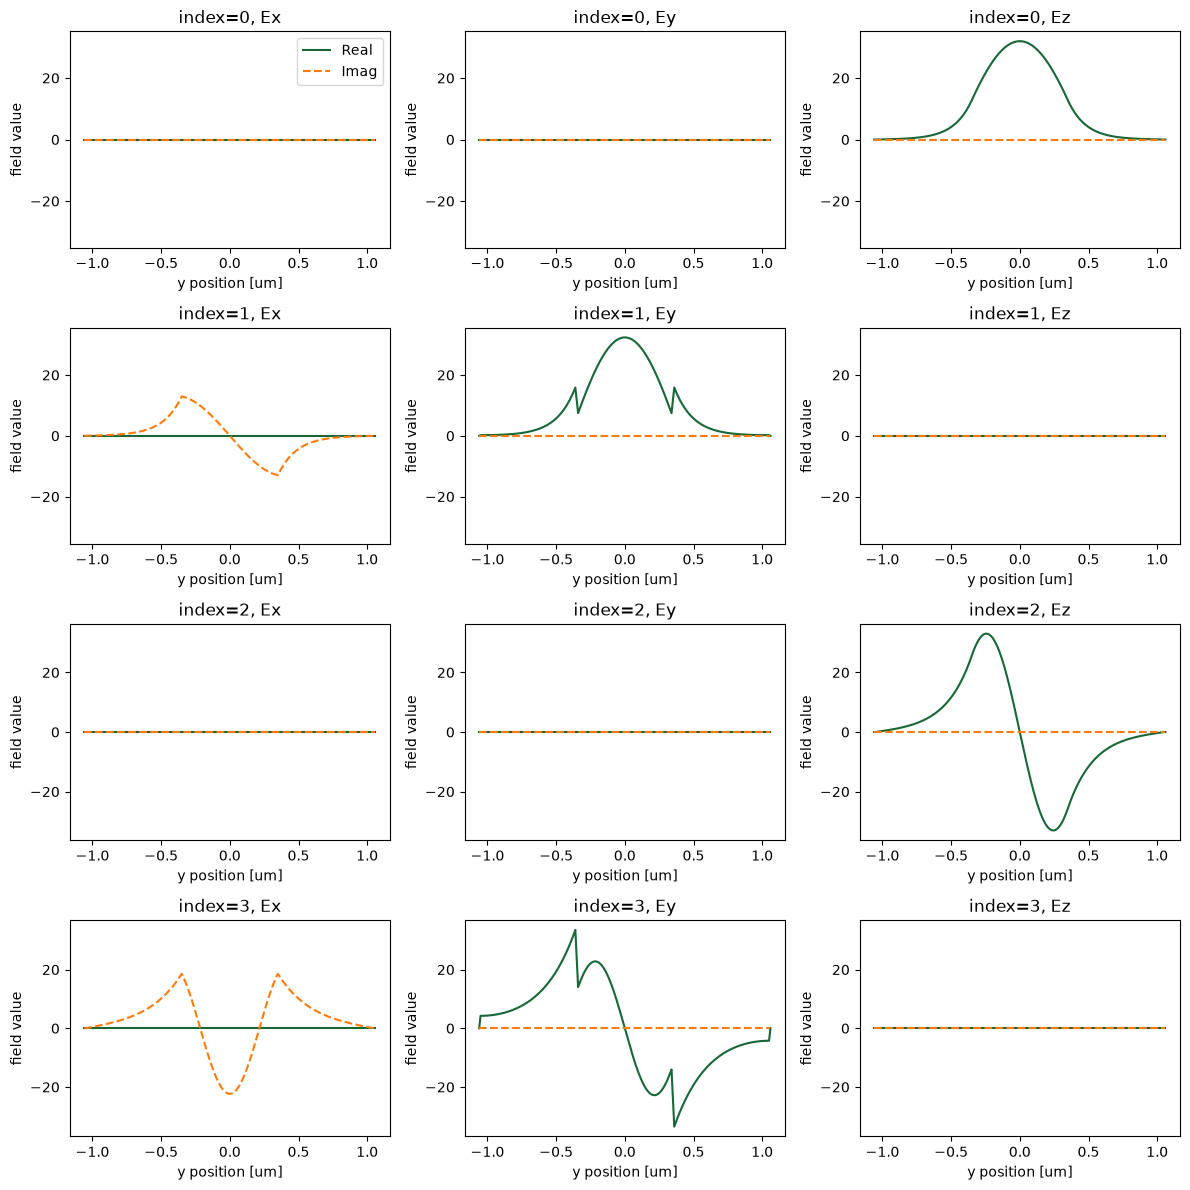

In [8]:
fig, axs = plt.subplots(num_modes, 3, figsize=(12, 12), tight_layout=True)
for mode_index in range(num_modes):
    vmax = 1.1 * max(
        abs(modes.field_components[n].sel(mode_index=mode_index)).max() for n in ("Ex", "Ey", "Ez")
    )
    for field_name, ax in zip(("Ex", "Ey", "Ez"), axs[mode_index]):
        field = modes.field_components[field_name].sel(mode_index=mode_index)
        field.real.plot(label="Real", ax=ax)
        field.imag.plot(ls="--", label="Imag", ax=ax)
        ax.set_title(f"index={mode_index}, {field_name}")
        ax.set_ylim(-vmax, vmax)

axs[0, 0].legend()

print("Effective index of computed modes: ", np.array(modes.n_eff))

We want to inject the fundamental, Ez-polarized input into the 1st order
Ez-polarized input.

From the plots, we see that these modes correspond to the first and
third rows, or `mode_index=0` and `mode_index=2`, respectively.

So we make sure that the `mode_index_in` and `mode_index_out` variables
are set appropriately and we set a `ModeSpec` with 3 modes to be able to
capture the `mode_index_out` in our output data.

In [9]:
mode_index_in = 0
mode_index_out = 2

num_modes = max(mode_index_in, mode_index_out) + 1

mode_spec = td.ModeSpec(num_modes=num_modes)

Then it is straightforward to generate our source and monitor.

In [10]:
# source seeding the simulation
forward_source = td.ModeSource(
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freqw),
    center=[source_x, 0, 0],
    size=mode_size,
    mode_index=mode_index_in,
    mode_spec=mode_spec,
    direction="+",
)

# we'll refer to the measurement monitor by this name often
measurement_monitor_name = "measurement"

# monitor where we compute the objective function from
measurement_monitor = td.ModeMonitor(
    center=[meas_x, 0, 0],
    size=mode_size,
    freqs=[freq0],
    mode_spec=mode_spec,
    name=measurement_monitor_name,
)

Finally, we create a new function that calls our `make_sim_base()`
function and adds the source and monitor to the result. This is the
function we will use in our objective function to generate our
`td.Simulation` given the input parameters.

In [11]:
def make_sim(params, beta):
    sim = make_sim_base(params, beta=beta)
    return sim.updated_copy(sources=[forward_source], monitors=[measurement_monitor])

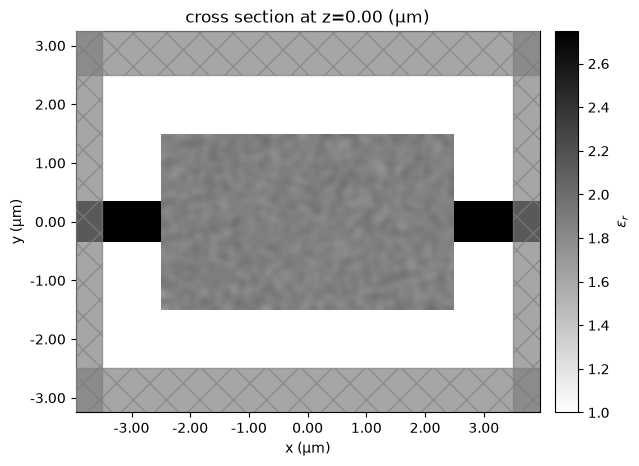

In [12]:
sim_start = make_sim_base(params0, beta=1.0)

ax = sim_start.plot_eps(z=0, freq=freq0)

plt.show()

### Post Processing

Next, we will define a function to tell us how we want to postprocess
the output `td.SimulationData` object to give the conversion power that
we are interested in maximizing.

In [13]:
def measure_power(sim_data: td.SimulationData) -> float:
    """Return the power in the output_data amplitude at the mode index of interest."""
    output_amps = sim_data["measurement"].amps
    amp = output_amps.sel(direction="+", f=freq0, mode_index=mode_index_out).values
    return anp.sum(anp.abs(amp) ** 2)

Then, we add a penalty to produce structures that are invariant under
erosion and dilation, which is a useful approach to implementing minimum
length scale features.

In [14]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

penalty = make_erosion_dilation_penalty(radius, lx / nx)

### Define Objective Function

Finally, we need to define the objective function that we want to
maximize as a function of our input parameters (permittivity of each
pixel) that returns the conversion power. This is the function we will
differentiate later.

In [15]:
def J(params: np.ndarray, beta: float, step_num: int = None, verbose: bool = False) -> float:
    sim = make_sim(params, beta=beta)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    penalty_weight = np.minimum(1, beta / 25)
    density = filter_project(params, beta)
    return measure_power(sim_data) - penalty_weight * penalty(density)

## Inverse Design

Now we are ready to perform the optimization.

We use the `autograd.value_and_grad` function to get the gradient of `J`
with respect to the permittivity of each `Box`, while also returning the
converted power associated with the current iteration, so we can record
this value for later.

Let’s try running this function once to make sure it works.

In [16]:
dJ_fn = value_and_grad(J)

In [17]:
val, grad = dJ_fn(params0, beta=1, verbose=True)
print(grad.shape)

16:59:32 SE Asia Standard Time Created task 'inv_des' with resource_id          
                               'fdve-88584bd3-6c38-41f7-87d3-34ea30805733' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=8277090;https://tidy3d.simulation.cloud/workbench?taskId=fdve-88584bd3-6c38-41f7-87d3-34ea30805733\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=8277091;https://tidy3d.simulation.cloud/workbench?taskId=fdve-88584bd3-6c38-41f7-87d3-34ea30805733\taskId]8;;\
                               ]8;id=8277090;https://tidy3d.simulation.cloud/workbench?taskId=fdve-88584bd3-6c38-41f7-87d3-34ea30805733\=]8;;\]8;id=8277092;https://tidy3d.simulation.cloud/workbench?taskId=fdve-88584bd3-6c38-41f7-87d3-34ea30805733\fdve]8;;\]8;id=8277090;https://tidy3d.simulation.cloud/workbench?taskId=fdve-88584bd3-6c38-41f7-87d3-34ea30805733\-88584bd3-6c38-41f7-87d3-34ea30805733']8;;\.

                               Task folder: ]8;id=8277095;https://tidy3d.simulation.cloud/folders/folder-0115173b-c38d-46ac-ae26-956a6110dbd7\'default']8;;\.

Output()

Output()

...

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

17:00:54 SE Asia Standard Time Batch complete.

Output()

(500, 300)


In [18]:
print(grad)

[[ 1.30448281e-08  2.56903706e-08  2.49141191e-08 ... -5.51629763e-09
  -5.60823728e-09 -2.82917917e-09]
 [ 2.62371391e-08  5.17052097e-08  5.01801472e-08 ... -1.10785709e-08
  -1.12887426e-08 -5.69075057e-09]
 [ 2.68753065e-08  5.30190515e-08  5.13777989e-08 ... -1.13478570e-08
  -1.16443294e-08 -5.88133074e-09]
 ...
 [ 3.53361604e-07  7.07449596e-07  7.15411666e-07 ... -6.03453396e-07
  -5.92602723e-07 -2.94517997e-07]
 [ 3.51756403e-07  7.04237841e-07  7.12307942e-07 ... -5.96807575e-07
  -5.85891108e-07 -2.91144299e-07]
 [ 1.75669434e-07  3.51709131e-07  3.55678319e-07 ... -2.97327950e-07
  -2.91850760e-07 -1.45027314e-07]]


### Optimization

We will use “Adam” optimization strategy to perform sequential updates
of each of the permittivity values in the `td.CustomMedium`.

For more information on what we use to implement this method, see [this
article](https://optimization.cbe.cornell.edu/index.php?title=Adam).

We will run 10 steps and measure both the permittivities and powers at
each iteration.

We run this process explicitly below with Tidy3D’s built-in Adam
optimizer.

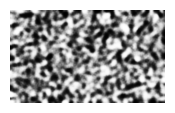

step = 1
	beta = 1.0000e+00
	J = -3.9947e-02
	grad_norm = 4.5917e-04


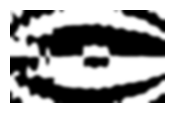

step = 2
	beta = 2.0000e+00
	J = 3.1480e-02
	grad_norm = 1.0605e-02


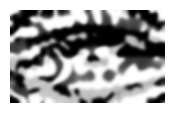

step = 3
	beta = 3.0000e+00
	J = -5.5024e-02
	grad_norm = 5.9953e-03


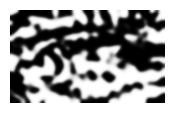

step = 4
	beta = 4.0000e+00
	J = 5.7787e-02
	grad_norm = 9.3648e-03


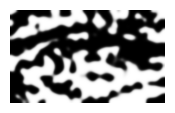

step = 5
	beta = 5.0000e+00
	J = 5.5118e-02
	grad_norm = 1.4990e-02


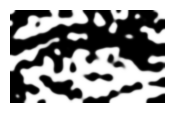

step = 6
	beta = 6.0000e+00
	J = 2.2761e-01
	grad_norm = 1.7782e-02


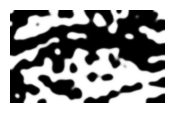

step = 7
	beta = 7.0000e+00
	J = 4.4847e-01
	grad_norm = 1.6799e-02


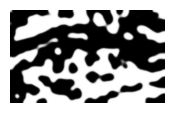

step = 8
	beta = 8.0000e+00
	J = 4.5312e-01
	grad_norm = 2.5898e-02


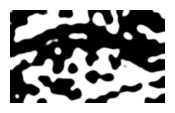

step = 9
	beta = 9.0000e+00
	J = 6.5154e-01
	grad_norm = 1.3416e-02


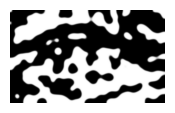

step = 10
	beta = 1.0000e+01
	J = 6.9846e-01
	grad_norm = 2.3288e-02


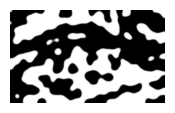

step = 11
	beta = 1.1000e+01
	J = 7.1357e-01
	grad_norm = 2.0917e-02


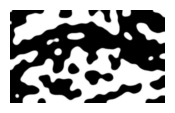

step = 12
	beta = 1.2000e+01
	J = 8.2066e-01
	grad_norm = 8.9587e-03


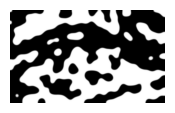

step = 13
	beta = 1.3000e+01
	J = 8.4870e-01
	grad_norm = 8.5883e-03


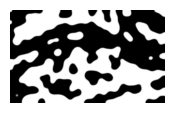

step = 14
	beta = 1.4000e+01
	J = 8.7528e-01
	grad_norm = 6.1341e-03


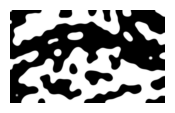

step = 15
	beta = 1.5000e+01
	J = 8.8783e-01
	grad_norm = 5.7651e-03


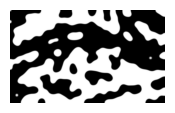

step = 16
	beta = 1.6000e+01
	J = 9.0157e-01
	grad_norm = 4.6736e-03


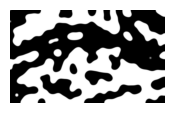

step = 17
	beta = 1.7000e+01
	J = 9.0929e-01
	grad_norm = 4.1446e-03


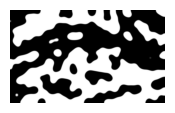

step = 18
	beta = 1.8000e+01
	J = 9.1712e-01
	grad_norm = 3.5312e-03


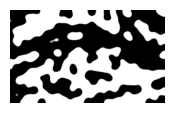

step = 19
	beta = 1.9000e+01
	J = 9.2186e-01
	grad_norm = 4.7778e-03


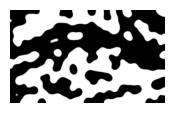

step = 20
	beta = 2.0000e+01
	J = 9.2174e-01
	grad_norm = 6.8161e-03


In [19]:
from tidy3d.plugins.autograd import adam, apply_updates

# hyperparameters
num_steps = 20
learning_rate = 1.0

# initialize adam optimizer with starting parameters
params = np.array(params0)
optimizer = adam(learning_rate=learning_rate)
opt_state = optimizer.init(params)

# store history
Js = []
params_history = [params]
beta_history = []

# gradually increase the binarization strength
beta0 = 1
beta_increment = 1

for i in range(num_steps):
    # compute gradient and current objective function value

    density = filter_project(params, beta)
    plt.subplots(figsize=(2, 2))
    plt.imshow(np.flipud(1 - density.T), cmap="gray")
    plt.axis("off")
    plt.show()

    beta = beta0 + i * beta_increment
    value, gradient = dJ_fn(params, step_num=i + 1, beta=beta)

    # outputs
    print(f"step = {i + 1}")
    print(f"\tbeta = {beta:.4e}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = apply_updates(params, updates)

    # cap the parameters
    anp.clip(params, 0.0, 1.0, out=params)

    # save history
    Js.append(value)
    params_history.append(params.copy())
    beta_history.append(beta)

power = J(params_history[-1], beta=beta)
Js.append(power)

In [20]:
params_final = params_history[-1]

Let’s run the optimize function.

and then record the final power value (including the last iteration’s
parameter updates).

### Results

First, we plot the objective function (power converted to 1st order
mode) as a function of step and notice that it converges nicely!

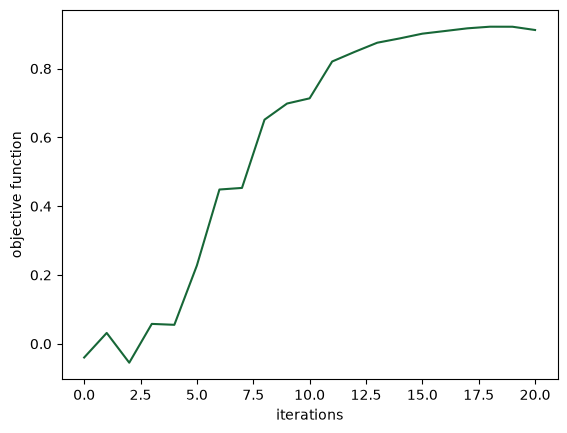

In [21]:
plt.plot(Js)
plt.xlabel("iterations")
plt.ylabel("objective function")
plt.show()

We then will visualize the final structure, so we convert it to a
regular `Simulation` using the final permittivity values and plot it.

In [22]:
sim_final = make_sim(params_final, beta=beta)

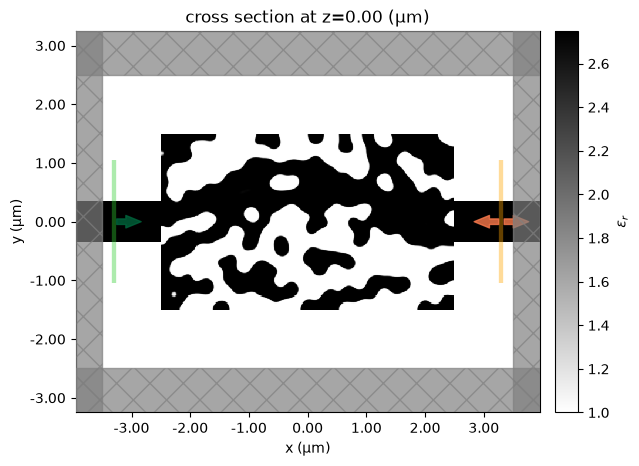

In [23]:
sim_final.plot_eps(z=0, freq=freq0)
plt.show()

Finally, we want to inspect the fields, so we add a field monitor to the
`Simulation` and perform one more run to record the field values for
plotting.

In [24]:
field_mnt = td.FieldMonitor(
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="field_mnt",
)

sim_final = sim_final.copy(update=dict(monitors=(field_mnt, measurement_monitor)))

In [25]:
sim_data_final = web.run(sim_final, task_name="inv_des_final")

18:04:13 SE Asia Standard Time Created task 'inv_des_final' with resource_id    
                               'fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=8277104;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=8277105;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\taskId]8;;\
                               ]8;id=8277104;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\=]8;;\]8;id=8277106;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\fdve]8;;\]8;id=8277104;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\-767c8297-29ae-4ef4-8019-da8a1afd41ad']8;;\.

                               Task folder: ]8;id=8277108;https://tidy3d.simulation.cloud/folders/folder-0115173b-c38d-46ac-ae26-956a6110dbd7\'default']8;;\.

Output()

18:04:32 SE Asia Standard Time Estimated FlexCredit cost: 0.025. This assumes   
                               the FDTD solver runs for the full simulation     
                               time; if early shutoff is reached, the billed    
                               cost can be lower. Use 'web.real_cost(task_id)'  
                               to get the billed FlexCredit cost after a        
                               simulation run.

...

18:04:50 SE Asia Standard Time early shutoff detected at 11%, exiting.

18:04:51 SE Asia Standard Time status = success

                               View simulation result at                        
                               ]8;id=8277111;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=8277112;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\taskId]8;;\
                               ]8;id=8277111;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\=]8;;\]8;id=8277113;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\fdve]8;;\]8;id=8277111;https://tidy3d.simulation.cloud/workbench?taskId=fdve-767c8297-29ae-4ef4-8019-da8a1afd41ad\-767c8297-29ae-4ef4-8019-da8a1afd41ad']8;;\.

Output()

18:07:18 SE Asia Standard Time Loading results from simulation_data.hdf5

We notice that the behavior is as expected and the device performs
exactly how we intended!

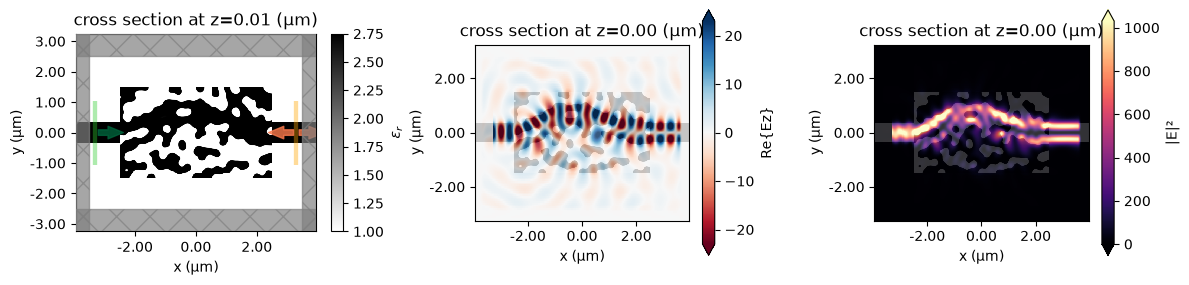

In [26]:
f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3), tight_layout=True)
sim_final.plot_eps(z=0.01, freq=freq0, ax=ax0)
ax1 = sim_data_final.plot_field("field_mnt", "Ez", z=0, ax=ax1)
ax2 = sim_data_final.plot_field("field_mnt", "E", "abs^2", z=0, ax=ax2)

The final device converts more than 90% of the input power to the 1st
mode, up from \< 1% when we started.

In [27]:
final_power = (
    sim_data_final["measurement"].amps.sel(direction="+", f=freq0, mode_index=mode_index_out).abs
    ** 2
)
print(f"Final power conversion = {final_power * 100:.2f}%")

Final power conversion = 94.21%


## Export to GDS

The `Simulation` object has the
[.to_gds_file](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html#tidy3d.Simulation.to_gds_file)
convenience function to export the final design to a `GDS` file. In
addition to a file name, it is necessary to set a cross-sectional plane
(`z = 0` in this case) on which to evaluate the geometry, a `frequency`
to evaluate the permittivity, and a `permittivity_threshold` to define
the shape boundaries in custom mediums. See the [GDS
export](https://www.flexcompute.com/tidy3d/examples/notebooks/GDSExport/)
notebook for a detailed example on using `.to_gds_file` and other GDS
related functions.

In [28]:
sim_final.to_gds_file(
    fname="./misc/inv_des_mode_conv.gds",
    z=0,
    frequency=freq0,
    permittivity_threshold=2.6,
)

---

## Pixelation: from free-form design to digital metamaterial

The optimization above is free-form — 500x300 parameters on a 10 nm grid, with a conic filter of
`radius = 0.120 um` setting the minimum feature size. A digital metamaterial instead has to be built
from square pixels on a fixed lattice (100 nm, matching `create_hybrid_rotator_90`).

So: **quantize the optimized design onto a 100 nm pixel lattice and re-simulate.** Each pixel takes the
mean of the fine cells beneath it; >= 0.5 becomes silicon, else air.

The loss splits into two parts that must be reported separately, or pixelation gets blamed for both:

| rung | design | what the drop to here measures |
|---|---|---|
| 1 | relaxed, beta = 20 | — (this is the 95.98% headline, and it still contains grey) |
| 2 | hard threshold on the fine 10 nm grid | **binarization** cost |
| 3 | quantized to 100 nm pixels | **pixelation** cost |

Rung 1 -> 2 is not free either: the upstream number is a *relaxed* one that was never re-simulated
after thresholding.


In [29]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty


def pixelate(density, pixel_size, offset=0):
    """Quantize a continuous density onto a square pixel lattice.

    Each pixel takes the MEAN of the fine cells beneath it; >= 0.5 becomes silicon, else air.
    Returns (bits, density_up), where density_up is back on the fine (nx, ny) grid and ready to
    simulate. `offset` shifts the lattice by that many fine cells -- a control for whether a result
    is a property of the pixel size or just an artifact of where the lattice happens to land.
    """
    k = int(round(pixel_size / dl_design_region))
    d = density
    if offset:
        # pad with edge values rather than wrapping, so the shift cannot fold a feature
        # from one side of the design region onto the other
        d = np.pad(d, ((offset, k - offset), (offset, k - offset)), mode="edge")
    h, w = d.shape
    nbx, nby = h // k, w // k
    coarse = d[: nbx * k, : nby * k].reshape(nbx, k, nby, k).mean(axis=(1, 3))
    bits = (coarse >= 0.5).astype(np.uint8)
    up = np.kron(bits.astype(float), np.ones((k, k)))
    if offset:
        up = up[offset : offset + density.shape[0], offset : offset + density.shape[1]]
    return bits, up


def sim_from_density(density):
    """Reuse sim_final's exact grid, mesh override, source and monitors, swapping ONLY the design
    structure. That is what makes the comparison fair -- the variants differ in geometry and in
    nothing else, so no resolution or meshing difference can contaminate the numbers."""
    box = td.Box(center=(0, 0, 0), size=(lx, ly, lz))
    eps_data = rescale(density, 1, eps_wg).reshape((nx, ny, 1))
    struct = td.Structure.from_permittivity_array(geometry=box, eps_data=eps_data)
    return sim_final.updated_copy(structures=[waveguide, struct])


def power_of(sim_data):
    """Converted power into mode_index_out -- same quantity cell 47 prints."""
    amp = sim_data["measurement"].amps.sel(direction="+", f=freq0, mode_index=mode_index_out)
    return float(np.abs(amp.values) ** 2)


# fabrication-quality metric, same one used in hybrid_rotator_90_invdes_2.ipynb, on the PIXEL
# lattice (dl = 1 pixel). 0 = clean blobs, 1 = 1-px lamination or checkerboard.
ed_penalty = make_erosion_dilation_penalty(radius=1.5, dl=1.0)

# --- offline checks, no simulation, no credits -------------------------------
# Only pixel sizes whose k divides BOTH nx and ny land on an exact lattice.
_ok = [k for k in range(1, 101) if nx % k == 0 and ny % k == 0]
print(f"exact pixel sizes on this grid: {[f'{k * dl_design_region * 1000:.0f}nm' for k in _ok]}")
print("  (note 150 nm is NOT available: k=15 does not divide 500)")

_d = filter_project(params_final, beta)
_b, _u = pixelate(_d, 0.1)
assert _b.shape == (nx // 10, ny // 10) == (50, 30), _b.shape
assert _u.shape == (nx, ny)
_blocks = _u.reshape(50, 10, 30, 10)
assert np.abs(_blocks - _blocks[:, :1, :, :1]).max() == 0, "upsampled design is not pixel-constant"
assert set(np.unique(_u)) <= {0.0, 1.0}, "quantized density must be binary"
print(f"\npixelate() OK: {_d.shape} -> bits {_b.shape} -> {_u.shape}, pixel-constant, binary")
print(f"fill fraction: relaxed {_d.mean() * 100:.1f}%  "
      f"fine-binary {(_d >= 0.5).mean() * 100:.1f}%  100nm {_u.mean() * 100:.1f}%")
print(f"area that flips on quantization: {np.mean(_u != (_d >= 0.5)) * 100:.2f}%")

# and the fair-comparison guarantee: only `structures` differs from sim_final
_s = sim_from_density(_u)
assert _s.grid_spec == sim_final.grid_spec, "grid differs -- comparison would be contaminated"
assert _s.monitors == sim_final.monitors and _s.sources == sim_final.sources
assert _s.run_time == sim_final.run_time and _s.boundary_spec == sim_final.boundary_spec
print("sim_from_density() OK: grid, sources, monitors, run_time all identical to sim_final")


exact pixel sizes on this grid: ['10nm', '20nm', '40nm', '50nm', '100nm', '200nm', '250nm', '500nm', '1000nm']
  (note 150 nm is NOT available: k=15 does not divide 500)

pixelate() OK: (500, 300) -> bits (50, 30) -> (500, 300), pixel-constant, binary
fill fraction: relaxed 52.3%  fine-binary 52.3%  100nm 51.9%
area that flips on quantization: 6.72%
sim_from_density() OK: grid, sources, monitors, run_time all identical to sim_final


In [30]:
# --- the three-rung ladder ---------------------------------------------------
density_relaxed = filter_project(params_final, beta)          # rung 1, already simulated above
density_fine = (density_relaxed >= 0.5).astype(float)         # rung 2, free-form but binary @10nm
bits_100, density_100 = pixelate(density_relaxed, 0.1)        # rung 3, digital metamaterial

sim_fine = sim_from_density(density_fine)
sim_100 = sim_from_density(density_100)

batch = web.Batch(simulations={"fine_binary": sim_fine, "px_100nm": sim_100},
                  verbose=True)
batch_data = batch.run(path_dir="./misc")

P_relaxed = float(final_power)                 # from cell 47
P_fine = power_of(batch_data["fine_binary"])
P_100 = power_of(batch_data["px_100nm"])

print(f"\n{'rung':<34}{'power':>9}{'vs relaxed':>13}{'vs fine-bin':>13}")
print(f"{'1. relaxed (beta=20, has grey)':<34}{P_relaxed * 100:>8.2f}%{'--':>13}{'--':>13}")
print(f"{'2. hard threshold, free-form 10nm':<34}{P_fine * 100:>8.2f}%"
      f"{(P_fine - P_relaxed) * 100:>+12.2f}{'--':>13}")
print(f"{'3. quantized to 100nm pixels':<34}{P_100 * 100:>8.2f}%"
      f"{(P_100 - P_relaxed) * 100:>+12.2f}{(P_100 - P_fine) * 100:>+12.2f}")
print(f"\n  binarization cost (1 -> 2): {(P_relaxed - P_fine) * 100:+.2f} points")
print(f"  PIXELATION cost   (2 -> 3): {(P_relaxed - P_100 - (P_relaxed - P_fine)) * 100:+.2f} points"
      f"   <-- the answer to the question")
print(f"\nfabrication quality on the 100nm lattice: fill {bits_100.mean() * 100:.1f}%, "
      f"ED penalty {float(ed_penalty(bits_100.astype(float))):.4f}")


Output()

18:07:41 SE Asia Standard Time Started working on Batch containing 2 tasks.

18:08:00 SE Asia Standard Time Maximum FlexCredit cost: 0.050 for the whole     
                               batch.

                               Use 'Batch.real_cost()' to get the billed        
                               FlexCredit cost after completion.

Output()

18:08:03 SE Asia Standard Time Batch complete.


rung                                  power   vs relaxed  vs fine-bin
1. relaxed (beta=20, has grey)       94.21%           --           --
2. hard threshold, free-form 10nm    94.19%       -0.02           --
3. quantized to 100nm pixels         86.77%       -7.44       -7.42

  binarization cost (1 -> 2): +0.02 points
  PIXELATION cost   (2 -> 3): +7.42 points   <-- the answer to the question

fabrication quality on the 100nm lattice: fill 51.9%, ED penalty 0.3170


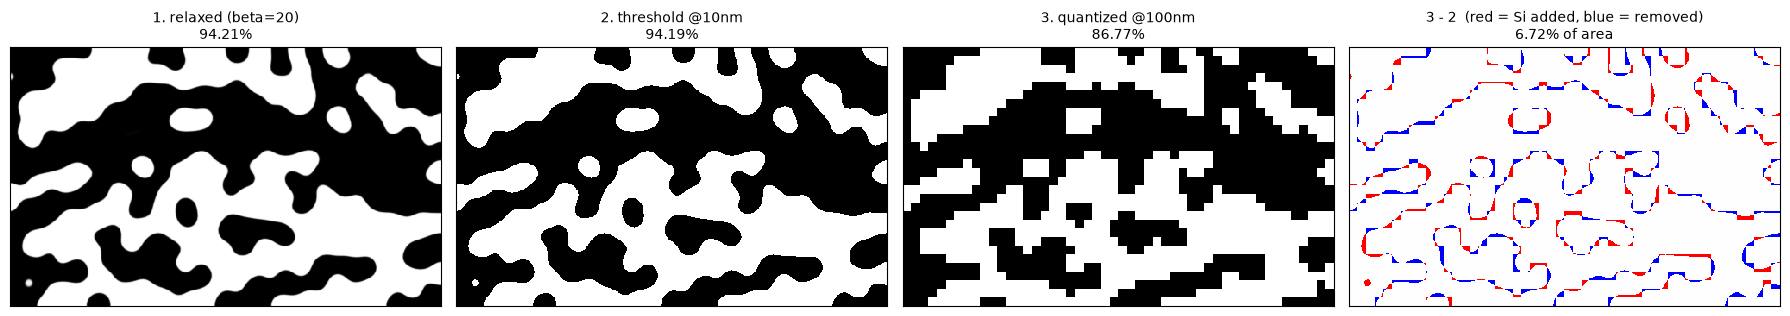

In [31]:
# --- what actually changed ---------------------------------------------------
f, axs = plt.subplots(1, 4, figsize=(18, 3.2), tight_layout=True)
for ax, (d, t) in zip(axs, [
    (density_relaxed, f"1. relaxed (beta={beta})\n{P_relaxed * 100:.2f}%"),
    (density_fine, f"2. threshold @10nm\n{P_fine * 100:.2f}%"),
    (density_100, f"3. quantized @100nm\n{P_100 * 100:.2f}%"),
]):
    ax.imshow(np.flipud(1 - d.T), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

diff = density_100 - density_fine
axs[3].imshow(np.flipud(diff.T), cmap="bwr", vmin=-1, vmax=1, interpolation="nearest")
axs[3].set_title(f"3 - 2  (red = Si added, blue = removed)\n"
                 f"{np.mean(diff != 0) * 100:.2f}% of area", fontsize=10)
axs[3].set_xticks([]); axs[3].set_yticks([])
plt.show()


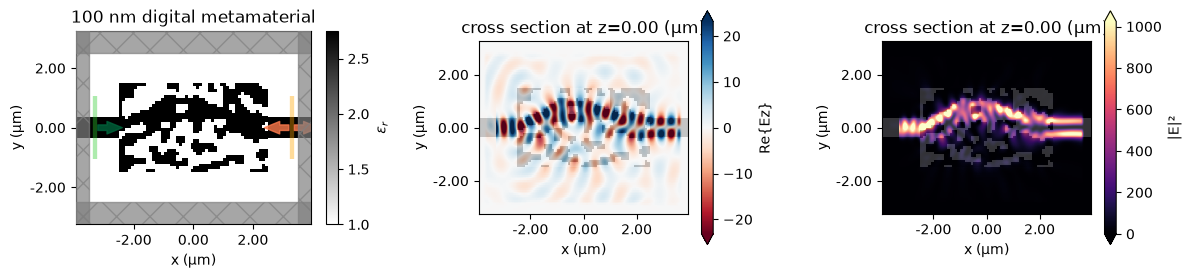

Final power conversion (100 nm digital metamaterial) = 86.77%
Free-form relaxed reference                          = 94.21%


In [32]:
# --- fields of the 100 nm digital metamaterial (mirrors cell 45) -------------
sim_data_100 = batch_data["px_100nm"]

f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3), tight_layout=True)
sim_100.plot_eps(z=0.01, freq=freq0, ax=ax0)
ax1 = sim_data_100.plot_field("field_mnt", "Ez", z=0, ax=ax1)
ax2 = sim_data_100.plot_field("field_mnt", "E", "abs^2", z=0, ax=ax2)
ax0.set_title("100 nm digital metamaterial")
plt.show()

print(f"Final power conversion (100 nm digital metamaterial) = {P_100 * 100:.2f}%")
print(f"Free-form relaxed reference                          = {P_relaxed * 100:.2f}%")


In [33]:
# --- export: bit array + GDS -------------------------------------------------
# Flat ordering matches create_hybrid_rotator_90 (rows = y descending, cols = x ascending),
# the same convention hybrid_rotator_90_invdes_2.ipynb uses.
def to_bitstring(bits_2d):
    """(n_bx, n_by) indexed [x asc, y asc] -> flat, in create_hybrid_rotator_90 order."""
    return np.flip(bits_2d, axis=1).T.ravel().astype(np.uint8)


flat_100 = to_bitstring(bits_100)
np.save("freeform_pixelated_bits.npy", flat_100)
print(f"saved freeform_pixelated_bits.npy: {flat_100.shape}, "
      f"{bits_100.shape[0]} x {bits_100.shape[1]} pixels, fill {flat_100.mean() * 100:.1f}%")

# NOTE: this design region is ly = 3.0 um -> 50 x 30 = 1500 pixels, whereas
# create_hybrid_rotator_90 is rot_width = 1.5 um -> 50 x 15 = 750. Feeding this array to that
# function requires rot_width = 3.0. Not a problem here (this is the 2D TE0->TE1 toy), but it
# has to be reconciled before any of this reaches the real 3D rotator.

sim_100.to_gds_file(
    fname="./misc/inv_des_mode_conv_100nm.gds",
    z=0,
    frequency=freq0,
    permittivity_threshold=(1 + eps_wg) / 2,   # 1.875, the midpoint; design is already binary
)
print("wrote ./misc/inv_des_mode_conv_100nm.gds")


saved freeform_pixelated_bits.npy: (1500,), 50 x 30 pixels, fill 51.9%
wrote ./misc/inv_des_mode_conv_100nm.gds


### How coarse can the lattice go?

Same optimized design, quantized at several pixel sizes. The 100 nm entry is repeated with the lattice
shifted by half a pixel — if that control moves the result much, the number is an artifact of where the
grid lands rather than a property of the pixel size, and neither value should be quoted on its own.


18:19:31 SE Asia Standard Time Found all simulations in cache.


   pixel  offset      pixels   fill %  flipped %      ED    power  vs fine-bin
     10n       0   free-form    52.3%      0.00%   0.015   94.19%       +0.00
     50n       0      100x60    52.2%      3.48%   0.064   92.42%       -1.77
    100n       0       50x30    51.9%      6.72%   0.317   86.77%       -7.42
    100n       5       50x30    53.2%      6.70%   0.315   87.42%       -6.76
    200n       0       25x15    54.4%     13.41%   0.713   45.02%      -49.16
    250n       0       20x12    52.9%     15.72%   0.795   36.14%      -58.05


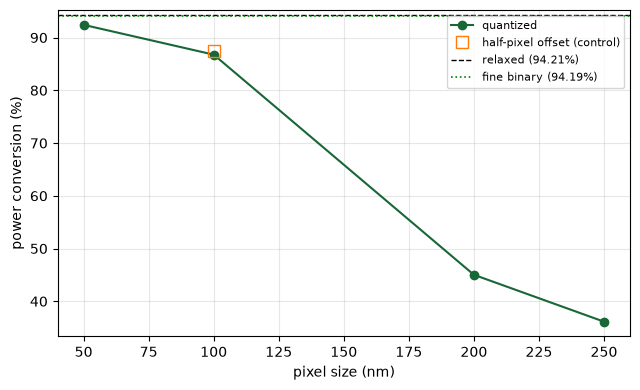

In [38]:
# --- pixel-size sweep + alignment control ------------------------------------
variants = {}
for px in (0.05, 0.20, 0.25):                       # 0.10 already run above
    _, d = pixelate(density_relaxed, px)
    variants[f"px_{int(px * 1000)}nm"] = (px, 0, sim_from_density(d), d)
_k100 = int(round(0.1 / dl_design_region))
_, d_off = pixelate(density_relaxed, 0.1, offset=_k100 // 2)
variants["px_100nm_offset"] = (0.1, _k100 // 2, sim_from_density(d_off), d_off)

sweep_data = web.Batch(simulations={k: v[2] for k, v in variants.items()},
                       verbose=True).run(path_dir="./misc")

rows = [(0.01, 0, P_fine, density_fine), (0.10, 0, P_100, density_100)]
for k, (px, off, _, d) in variants.items():
    rows.append((px, off, power_of(sweep_data[k]), d))
rows.sort(key=lambda r: (r[0], r[1]))

print(f"\n{'pixel':>8}{'offset':>8}{'pixels':>12}{'fill %':>9}{'flipped %':>11}"
      f"{'ED':>8}{'power':>9}{'vs fine-bin':>13}")
for px, off, P, d in rows:
    kk = int(round(px / dl_design_region))
    npix = f"{nx // kk}x{ny // kk}" if kk > 1 else "free-form"
    flip = np.mean(d != density_fine) * 100
    b = d[::kk, ::kk] if kk > 1 else d
    print(f"{px * 1000:>7.0f}n{off:>8d}{npix:>12}{d.mean() * 100:>8.1f}%{flip:>10.2f}%"
          f"{float(ed_penalty(b)):>8.3f}{P * 100:>8.2f}%{(P - P_fine) * 100:>+12.2f}")

fig, ax = plt.subplots(figsize=(6.5, 4), tight_layout=True)
main = [(px, P) for px, off, P, _ in rows if off == 0 and px > 0.01]
ax.plot([p * 1000 for p, _ in main], [P * 100 for _, P in main], "o-", label="quantized")
off_rows = [(px, P) for px, off, P, _ in rows if off != 0]
if off_rows:
    ax.plot([p * 1000 for p, _ in off_rows], [P * 100 for _, P in off_rows], "s",
            ms=9, mfc="none", label="half-pixel offset (control)")
ax.axhline(P_relaxed * 100, color="k", ls="--", lw=1, label=f"relaxed ({P_relaxed * 100:.2f}%)")
ax.axhline(P_fine * 100, color="g", ls=":", lw=1.2, label=f"fine binary ({P_fine * 100:.2f}%)")
ax.set_xlabel("pixel size (nm)"); ax.set_ylabel("power conversion (%)")
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()
